In [9]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.table import Table
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

import matplotlib.pyplot as plt

# Matplotlib configuration
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,           
    'ytick.right': True,         
    'xtick.minor.visible': True, 
    'ytick.minor.visible': True, 
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Pandas configuration
pd.set_option('display.max_columns', None)

# Paths configuration
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']
MAINPATH =  "/Users/jonginpark/sohnix/Research_Archive/2026/Park2026b-MACH-SMF"

%config InlineBackend.figure_format = 'retina'

In [10]:
# Load the field stellar mass function
field_result = pd.read_csv(f"{MAINPATH}/CODE/FIELD/FieldSMF_total.csv")
field_result.rename(columns={'logM': 'bin_centers'}, inplace=True)

# Load the MACH cluster member catalog and filter for MACH clusters only
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)
mach_vac_data = hecs_vac_data[hecs_vac_data['CLID'].isin(MACHLIST)]

# Field SMF (Mass) Normalization 

In [11]:
import numpy as np
import astropy.units as u
from astropy.cosmology import LambdaCDM

# =============================================================
# Cosmological field volume and mass between two redshift shells
#
# Used to normalise the field SMF from counts per dex to
# number density per dex per unit field mass [M☉⁻¹ dex⁻¹],
# allowing a fair comparison with the cluster SMF.
# =============================================================

# --- Cosmology (must match the rest of the analysis) ---
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# --- Redshift shell and survey footprint ---
z_lo, z_hi     = 0.07, 0.11          # redshift limits of the field sample
sky_fraction   = 0.1947              # fraction of full sky covered by the survey

# --- Comoving distances at shell boundaries [Mpc] ---
Dc_lo = cosmo.comoving_distance(z_lo).to(u.Mpc).value
Dc_hi = cosmo.comoving_distance(z_hi).to(u.Mpc).value

# --- Comoving field volume [Mpc³]
#   V = (4π/3) × f_sky × (D_c,hi³ − D_c,lo³)
field_volume = (4 * np.pi * sky_fraction / 3) * (Dc_hi**3 - Dc_lo**3)

# --- Total matter mass in the field volume [M☉]
#   M_field = Ω_m × ρ_crit,0 × V
#   (using the present-day critical density since volume is comoving)
rho_crit0  = cosmo.critical_density0.to(u.Msun / u.Mpc**3).value
field_mass = cosmo.Om0 * rho_crit0 * field_volume

print(f"Comoving volume  (z={z_lo}–{z_hi}): {field_volume:.3e} Mpc³")
print(f"Total matter mass in volume       : {field_mass:.3e} M☉")

# =============================================================
# Normalise the field SMF
#
#   phi_count_per_dex   = Φ [Mpc⁻³ dex⁻¹] × V  →  N per dex in the volume
#   phi_mass_normalized = N per dex / M_field × 1e15
#                       = N per dex per (10¹⁵ M☉ of matter)
#   This puts the field SMF on the same per-cluster-mass footing
#   as the cluster SMF.
# =============================================================
field_result['phi_count_per_dex']    = field_result['phi_Mpc-3_dex-1'] * field_volume
field_result['phi_mass_normalized']  = field_result['phi_count_per_dex'] / field_mass * 1e15

Comoving volume  (z=0.07–0.11): 5.803e+07 Mpc³
Total matter mass in volume       : 2.368e+18 M☉


# Cluster SMF (Mass) Normalization

In [12]:
import numpy as np
import pandas as pd

# =============================================================
# Load helper: reads a stacked-SMF .npz and returns the same
# dict structure used throughout the notebook.
# =============================================================
def load_mach_total_results(path):
    """Load a stacked-SMF .npz; returns result dict with fit_results."""
    d = np.load(path, allow_pickle=True)
    fit_labels = list(d['fit_labels'])
    fit_results = {
        lbl: (d['fit_median'][i], d['fit_lower'][i], d['fit_upper'][i])
        for i, lbl in enumerate(fit_labels)
    }
    return {
        'mean_all':       d['mean_all'],
        'mean_quenched':  d['mean_quenched'],
        'mean_sf':        d['mean_sf'],
        'original_counts':d['original_counts'],
        'bin_centers':    d['bin_centers'],
        'complimit':      float(d['complim']),
        'fit_results':    fit_results,
    }

# =============================================================
# Load R200 and R500 results
# =============================================================
result_r200 = load_mach_total_results('./SMF_results/MACH_total_results_R200.npz')
result_r500 = load_mach_total_results('./SMF_results/MACH_total_results_R500.npz')

# =============================================================
# Convert to DataFrame for easy column-wise access
# =============================================================
def result_to_df(res):
    return pd.DataFrame({
        'mean_all':        res['mean_all'],
        'mean_quenched':   res['mean_quenched'],
        'mean_sf':         res['mean_sf'],
        'original_counts': res['original_counts'],
        'bin_centers':     res['bin_centers'],
    })

df_r200 = result_to_df(result_r200)
df_r500 = result_to_df(result_r500)

In [13]:
# MACH cluster properties
num_mach_clusters = len(MACHLIST)  # Number of MACH clusters
total_m200_mass = mach_vac_data['M200'].sum()  # Sum of M200 masses (solar masses)
total_m500_mass = mach_vac_data['M500'].sum()  # Sum of M500 masses (solar masses)

# Normalize mass functions for MACH clusters (R200 and R500)
bin_width_r200 = np.diff(df_r200['bin_centers'])[0]
bin_width_r500 = np.diff(df_r500['bin_centers'])[0]

df_r200['phi_mass_normalized'] = (
    df_r200['mean_all'] * num_mach_clusters / bin_width_r200 / total_m200_mass * 1e15
)
df_r500['phi_mass_normalized'] = (
    df_r500['mean_all'] * num_mach_clusters / bin_width_r500 / total_m500_mass * 1e15
)


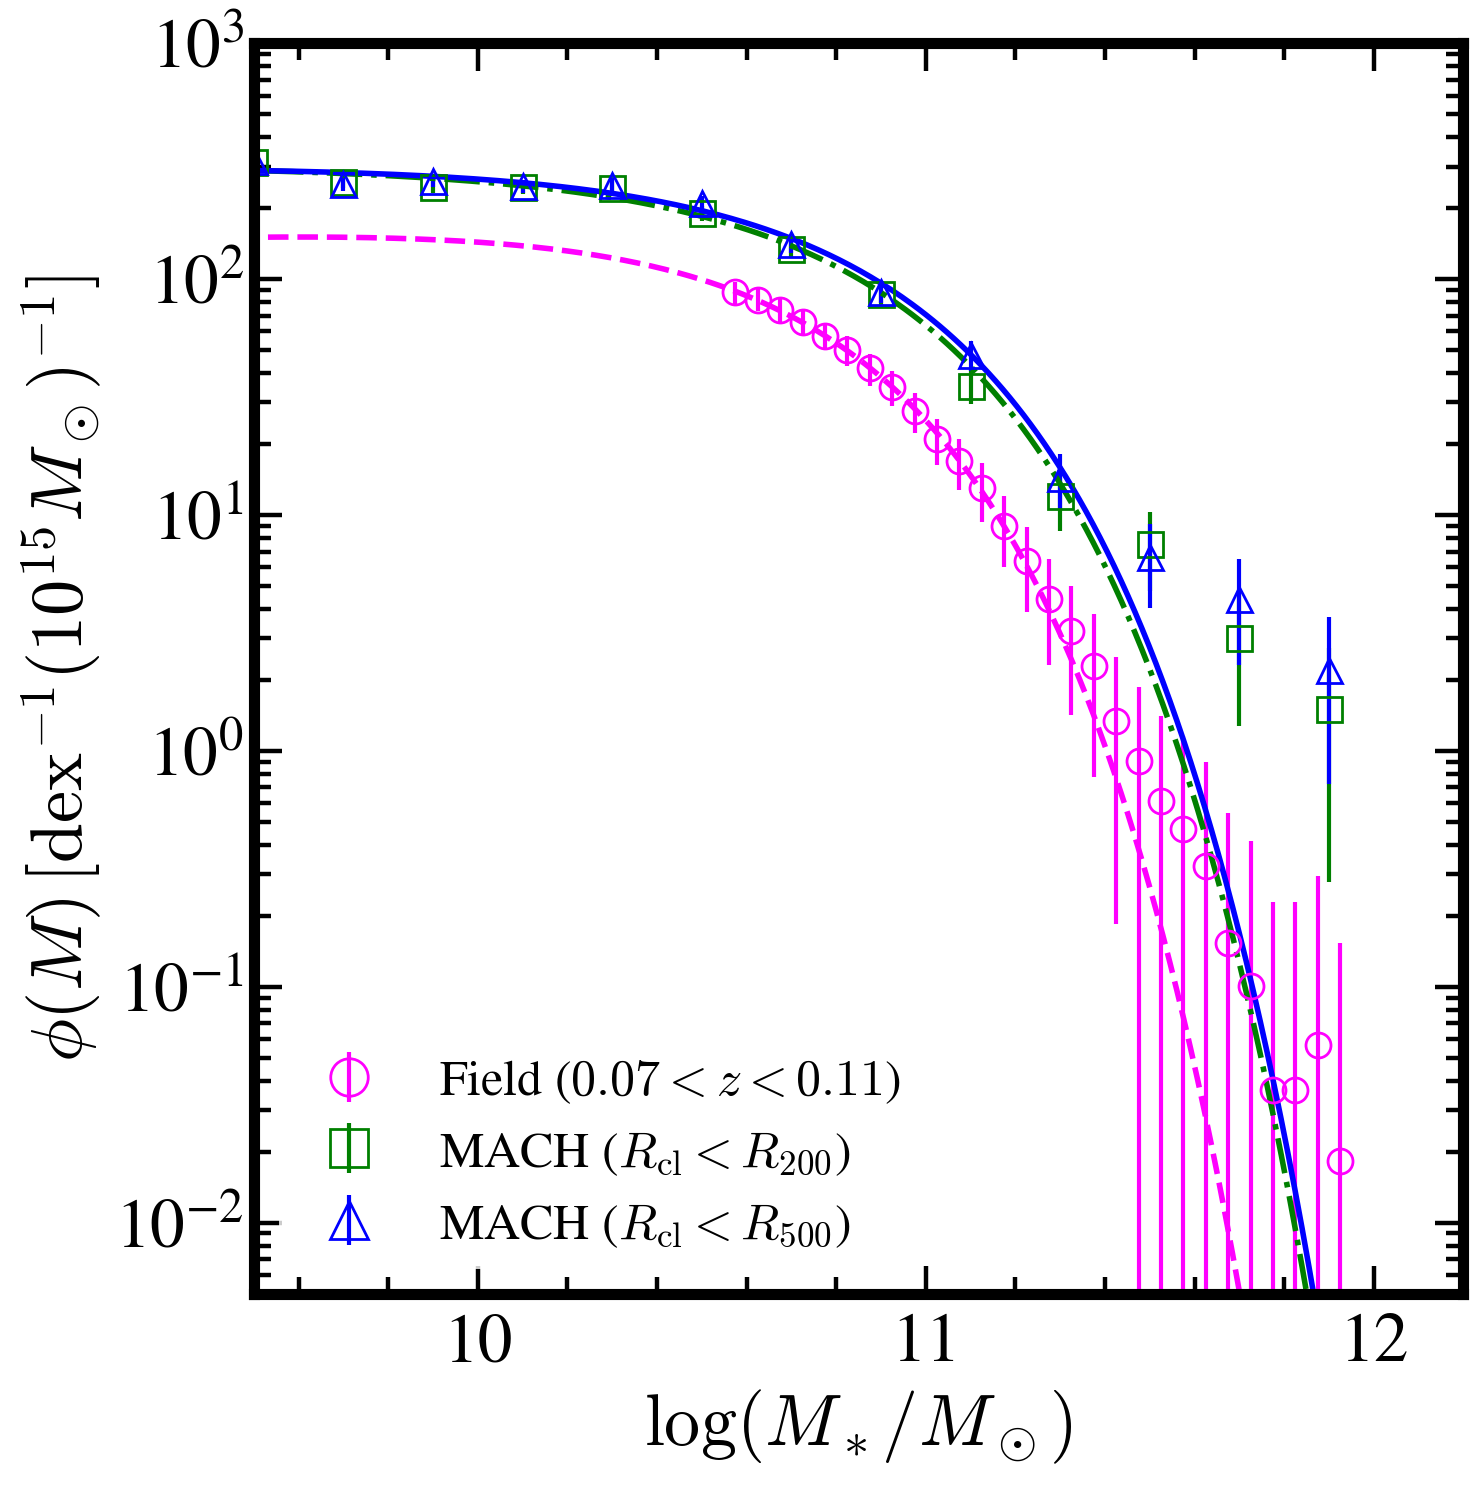

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling import models, fitting

# Define the Schechter function
@models.custom_model
def schechter_1D_SMF(M, phi_mass_normalized_0=133, M_star=10.65, alpha=-1.02):
    return (np.log(10) * phi_mass_normalized_0 *
            (10 ** ((1 + alpha) * -(M_star - M))) *
            np.exp(-10 ** -(M_star - M)))

# Assign the datasets
field_data         = field_result[field_result['bin_centers']>10.53] # field SMF limit defined
mach_r200_data     = df_r200
mach_r500_data     = df_r500

# Filter for fitting/plotting
field_filtered     = field_data[(field_data['bin_centers'] > 9.8) & (field_data['bin_centers'] < 12.2)]
mach_r200_filtered = mach_r200_data[mach_r200_data['bin_centers'] > 9.4]
mach_r500_filtered = mach_r500_data[mach_r500_data['bin_centers'] > 9.4]

# Compute Poisson errors
field_yerr     = np.sqrt(field_data['phi_mass_normalized'])
mach_r200_yerr = np.sqrt(mach_r200_filtered['phi_mass_normalized'])
mach_r500_yerr = np.sqrt(mach_r500_filtered['phi_mass_normalized'])

# Plot setup
fig, ax = plt.subplots(figsize=(8, 8))

# Field data (red)
ax.errorbar(
    field_data['bin_centers'], field_data['phi_mass_normalized'],
    yerr=field_yerr,
    fmt='o', markersize=9,
    markerfacecolor='none', markeredgecolor='magenta', markeredgewidth=1,
    ecolor='magenta', elinewidth=1.5,
    capsize=0,
    label=r'Field ($0.07<z<0.11$)'
)

# MACH R200 (green)
ax.errorbar(
    mach_r200_filtered['bin_centers'], mach_r200_filtered['phi_mass_normalized'],
    yerr=mach_r200_yerr,
    fmt='s', markersize=9,
    markerfacecolor='none', markeredgecolor='green', markeredgewidth=1,
    ecolor='green', elinewidth=1.5,
    capsize=0,
    label=r'MACH ($R_\mathrm{cl}<R_{200}$)'
)

# MACH R500 (blue)
ax.errorbar(
    mach_r500_filtered['bin_centers'], mach_r500_filtered['phi_mass_normalized'],
    yerr=mach_r500_yerr,
    fmt='^', markersize=9,
    markerfacecolor='none', markeredgecolor='blue', markeredgewidth=1,
    ecolor='blue', elinewidth=1.5,
    capsize=0,
    label=r'MACH ($R_\mathrm{cl}<R_{500}$)'
)

# Fit Schechter
fitter = fitting.LevMarLSQFitter()
init_model = schechter_1D_SMF()

fit_field     = fitter(init_model, field_filtered['bin_centers'], field_filtered['phi_mass_normalized'])
fit_mach_r200 = fitter(init_model, mach_r200_filtered['bin_centers'], mach_r200_filtered['phi_mass_normalized'])
fit_mach_r500 = fitter(init_model, mach_r500_filtered['bin_centers'], mach_r500_filtered['phi_mass_normalized'])

# Smooth x
x_fit = np.linspace(9.4, 12.5, 400)
y_fit_field     = fit_field(x_fit)
y_fit_mach_r200 = fit_mach_r200(x_fit)
y_fit_mach_r500 = fit_mach_r500(x_fit)

# Plot fits, thicker lines matching marker colors
ax.plot(x_fit, y_fit_field,     '--', linewidth=2, color='magenta')
ax.plot(x_fit, y_fit_mach_r200, '-.', linewidth=2, color='green')
ax.plot(x_fit, y_fit_mach_r500,  '-', linewidth=2, color='blue')

# Log scale, ticks, labels
ax.set_yscale('log')
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)

ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=26)
ax.set_ylabel(r'$\phi(M)\,[\mathrm{dex}^{-1}(10^{15}M_\odot)^{-1}]$', fontsize=26)
ax.set_xlim(9.5, 12.2)
ax.set_ylim(5e-3, 1000)

# Legend without box border
leg = ax.legend(fontsize=18, loc='lower left', markerscale=1.5, frameon=True)
leg.get_frame().set_linewidth(0)  # remove border

# Thicken plot borders
for spine in ax.spines.values():
    spine.set_linewidth(4)

plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure14.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [15]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# =============================================================
# Compute phi_cluster / phi_field ratio in the overlapping mass range
#
# Field and cluster SMFs live on different bin grids (different
# spacing), so a direct row-by-row ratio on the merged table
# is not meaningful. Instead we:
#   1. Drop NaN rows within each dataset.
#   2. Interpolate the field SMF onto the cluster bin centers
#      (cluster bins are the reference grid).
#   3. Compute ratio = phi_cluster / phi_field_interpolated.
#   4. Restrict to the overlapping mass range where all three
#      datasets have valid coverage.
# =============================================================

import pandas as pd

# =============================================================
# Build merged DataFrame: field + R200 + R500 mass-normalized SMF
#
# All three datasets are joined on bin_centers (outer merge).
# Rows with no data for a given bin show NaN in that column.
# =============================================================

# Select bin_centers + mass-normalized phi, rename for clarity
df_field = field_data[['bin_centers', 'phi_mass_normalized']].copy()
df_field = df_field.rename(columns={'phi_mass_normalized': 'phi_field'})

df_r200 = mach_r200_filtered[['bin_centers', 'phi_mass_normalized']].copy()
df_r200 = df_r200.rename(columns={'phi_mass_normalized': 'phi_r200'})

df_r500 = mach_r500_filtered[['bin_centers', 'phi_mass_normalized']].copy()
df_r500 = df_r500.rename(columns={'phi_mass_normalized': 'phi_r500'})

# Outer merge on bin_centers: keep all bins from all datasets
merged = (
    df_field
    .merge(df_r200, on='bin_centers', how='outer')
    .merge(df_r500, on='bin_centers', how='outer')
)

merged = merged.sort_values('bin_centers').reset_index(drop=True)

# --- Step 1: extract valid (non-NaN) rows for each dataset ---
field_valid = merged[merged['phi_field'].notna()][['bin_centers', 'phi_field']].sort_values('bin_centers')
r200_valid  = merged[merged['phi_r200' ].notna()][['bin_centers', 'phi_r200' ]].sort_values('bin_centers')
r500_valid  = merged[merged['phi_r500' ].notna()][['bin_centers', 'phi_r500' ]].sort_values('bin_centers')

# --- Step 2: determine common mass range covered by all three ---
M_min = max(field_valid['bin_centers'].min(),
            r200_valid ['bin_centers'].min(),
            r500_valid ['bin_centers'].min())
M_max = min(field_valid['bin_centers'].max(),
            r200_valid ['bin_centers'].max(),
            r500_valid ['bin_centers'].max())

print(f"Overlapping mass range: {M_min:.3f} – {M_max:.3f} log(M*/M☉)")

# --- Step 3: build interpolators for each dataset ---
# 'bounds_error=False' + 'fill_value=NaN' so points outside range → NaN
interp_field = interp1d(field_valid['bin_centers'], field_valid['phi_field'],
                        kind='linear', bounds_error=False, fill_value=np.nan)
interp_r200  = interp1d(r200_valid ['bin_centers'], r200_valid ['phi_r200'],
                        kind='linear', bounds_error=False, fill_value=np.nan)
interp_r500  = interp1d(r500_valid ['bin_centers'], r500_valid ['phi_r500'],
                        kind='linear', bounds_error=False, fill_value=np.nan)

# --- Step 4: define a common evaluation grid inside the overlap ---
M_grid = np.arange(np.ceil(M_min * 10) / 10,
                   np.floor(M_max * 10) / 10 + 0.1,
                   0.1)   # 0.1 dex steps; adjust as needed

phi_field_on_grid = interp_field(M_grid)
phi_r200_on_grid  = interp_r200 (M_grid)
phi_r500_on_grid  = interp_r500 (M_grid)

# --- Step 5: compute ratios ---
ratio_r200_field = phi_r200_on_grid / phi_field_on_grid
ratio_r500_field = phi_r500_on_grid / phi_field_on_grid

# --- Step 6: build and print results table ---
df_ratio = pd.DataFrame({
    'log_M':              M_grid,
    'phi_field':          phi_field_on_grid,
    'phi_r200':           phi_r200_on_grid,
    'phi_r500':           phi_r500_on_grid,
    'ratio_r200/field':   ratio_r200_field,
    'ratio_r500/field':   ratio_r500_field,
}).dropna()   # drop any bins still outside coverage

df_ratio = df_ratio.round(3)

print(f"\n{'log_M':>7}  {'phi_field':>12}  {'phi_r200':>12}  {'phi_r500':>12}  "
      f"{'r200/field':>12}  {'r500/field':>12}")
print('-' * 75)
for _, row in df_ratio.iterrows():
    print(f"{row['log_M']:>7.2f}  {row['phi_field']:>12.3f}  {row['phi_r200']:>12.3f}  "
          f"{row['phi_r500']:>12.3f}  {row['ratio_r200/field']:>12.3f}  "
          f"{row['ratio_r500/field']:>12.3f}")

print(f"\nMedian  r200/field = {df_ratio['ratio_r200/field'].median():.3f}")
print(f"Median  r500/field = {df_ratio['ratio_r500/field'].median():.3f}")

Overlapping mass range: 10.575 – 11.925 log(M*/M☉)

  log_M     phi_field      phi_r200      phi_r500    r200/field    r500/field
---------------------------------------------------------------------------
  10.60        84.840       162.051       175.427         1.910         2.068
  10.70        69.685       133.959       141.360         1.922         2.029
  10.80        53.773       110.253       114.855         2.050         2.136
  10.90        38.388        86.547        88.350         2.255         2.302
  11.00        24.249        60.959        67.919         2.514         2.801
  11.10        14.942        35.371        47.488         2.367         3.178
  11.20         7.709        23.706        30.923         3.075         4.011
  11.30         3.820        12.041        14.357         3.152         3.759
  11.40         1.816         9.784        10.492         5.387         5.777
  11.50         0.762         7.526         6.626         9.870         8.690
  11.60       